## Hyperbolic respiratory viral exceedance and comparison

- **Summary**: This document constructs exceedance probabilities for respiratory viral epidemics (influenza and coronaviruses) using the 1900-present data from [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) and the hyperbolic parametrization from [Fan et al. (2018)](https://www.dcp-3.org/sites/default/files/chapters/DCP3%20Volume%209_Ch%2018.pdf) and [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183). I use Bernstein et al.'s baseline model to select arrival rates of all and extreme respiratory viral epidemics. I then compare the hyperbolic exceedance function against that simulated by [Madhav et al. (2023)](https://www.cgdev.org/sites/default/files/estimated-future-mortality-pathogens-epidemic-and-pandemic-potential.pdf) and the one I previously constructed using Marani et al.'s method.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Aug 30, 2024

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


## 1. Set up exceedance probabilities from Madhav

In [3]:
## Create Madhav exceedance
severity = [0.001, 0.002, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
exceedance = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

df_madhav = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})


## 2. Prepare data for Bernstein's method

In [4]:
## Subset epidemics to those with observable severities
df_resp_viral_known = df_resp_viral[df_resp_viral['death_thousand'] > 0
                                   ].reset_index(drop=True)

## Subset epidemics to those in the last century
df_resp_viral_known = df_resp_viral_known[
                        df_resp_viral_known['year_start'] > 1900
                                        ].reset_index(drop=True)

## Display subsetted data
df_resp_viral_known


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0
2,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
3,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
4,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0
5,global sars,2003,2003,1,0.744,6.381185e+06,0.000117,0.001166,sars,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.500,6.872767e+06,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global mers,2012,2017,6,0.659,7.125828e+06,0.000092,0.000925,mers,viral,droplet,1,0,1,1
8,indian swine flu outbreak,2015,2015,1,2.000,7.379797e+06,0.000271,0.002710,influenza,viral,droplet,1,0,1,0
9,global covid-19,2019,2024,6,7100.000,7.740000e+06,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [5]:
## Define extreme severity threshold 
thresh = 10  ## Set to 10 SMU in accordance with Bernstein and Fan

## Define arrival and mean severity of all epidemics
p_a = 9 / 70  ## 9 epidemics in the past 70 years
mu_a = np.mean(df_resp_viral_known['severity_smu']) ## mean severity of all epidemics

## Define arrival and mean severity of extreme epidemics
p_x = 1 / 100  ## 1 extreme epidemic (1918 flu) in 100 years
mu_x = np.mean(df_resp_viral_known['severity_smu'][
    df_resp_viral_known['severity_smu'] >= thresh])  ## mean severity of extreme epidemics



In [6]:
## Find expected annual SMUs of all and extreme outbreaks
s_a = round(p_a * mu_a, 2)  ## expected annual severity of all outbreaks
s_x = round(p_x * mu_x, 2)  ## expected annual severity of extreme outbreaks

## Calibrate 'm'
m = round(1/(s_a), 2)  ## round 'm' to 2 decimals

## Display expected severities
print(f'Expected annual severity of all epidemics: {s_a} SMU')
print(f'Expected annual severity of extreme epidemics: {s_x} SMU')


Expected annual severity of all epidemics: 2.45 SMU
Expected annual severity of extreme epidemics: 1.71 SMU


In [7]:
## No rounding, in contrast to Bernstein
# s_a = p_a * mu_a
# s_x = p_x * mu_x
# m = 1/(s_a)

## 3. Calibrate hyperbolic exceedance function 

In [8]:
## Define function to calibrate 'f' with conditional first moment
def calibrate_hyperbolic_f(m, thresh, s_x):
    """
    Calibrate the parameter 'f' for a hyperbolic function from Fan et al. 
    (2018) based on the first moment conditional on exceedance.

    Parameters:
    - m: float, parameter of the hyperbolic model.
    - thresh: float, threshold value for extreme severities.
    - s_x: float, annual expected extreme severity.

    Returns:
    - f_opt: float, the optimal value of 'f' that minimizes the difference 
      between the integral and the conditional first moment.
    """
    
    ## Define integrand for hyperbolic exceedance
    def integrand(s, m, f):
        return (1 + m * (1 - f) * s) ** (-1 - 1 / (1 - f))
    
    ## Define the objective function to minimize
    def objective(f, m, s_x):
        integral, _ = quad(integrand, thresh, np.inf, args=(m, f))
        return (s_x - integral) ** 2
    
    ## Set bounds for 'f'
    bounds = [(-30, -1)]
    
    ## Minimize difference between integral and conditional moment
    ## x0 is the initial guess for 'f'
    result = minimize(objective, x0=-2, args=(m, s_x), bounds=bounds)
    
    ## Print result
    if result.success:
        if result.fun < 1e-08:
            print("Convergence succeeded! :)")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
        else:
            print("Convergence failed. :(")
            print(f"Minimized cost value: {result.fun}")
    else:
        print("Optimization failed. :(")
        print("Objective function value: NA")
    
    ## Return optimal value of 'f'
    f_opt = result.x[0] if result.success else None
    return f_opt

## Example usage:
## m = 0.23
## thresh = 10
## s_x = 2.97
## f = calibrate_hyperbolic_f(m, thresh, s_x)    



In [9]:
## Calibrate 'f'
f = calibrate_hyperbolic_f(m, thresh, s_x) 
f = round(f, 2)  ## round 'f' to 2 decimals

Convergence succeeded! :)
Minimized cost value: 3.946072931696825e-12
Optimal value of f: -9.72


In [10]:
print(f'Result: m = {m}, f = {f}')

Result: m = 0.41, f = -9.72


## 4. Calculate hyperbolic exceedance probabilities 

In [11]:
## Calculate Bernstein exceedance probabilities
exceedance = [(1 + m * (1 - f) * s)**(-1 - 1/(1 - f)) for s in severity]

## Create dataframe on exceedance probabilities
df_bernstein = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index
df_bernstein = df_bernstein.sort_values(by='severity', ascending=True)
df_bernstein = df_bernstein.reset_index(drop=True)

## Display severities and exceedance probabilities
# df_bernstein

## 5. Prepare Marani exceedance probabilities

In [12]:
## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_resp_viral_exceed = df_resp_viral[df_resp_viral['severity_smu'] >= thresh].reset_index(drop=True)

## Find arrival rate of extreme respiratory viral epidemics during 2001 to 2020
arrival = df_resp_viral_exceed[(df_resp_viral_exceed['year_start'] >= 2001) 
                               & (df_resp_viral_exceed['year_start'] <= 2020)].shape[0] / 20



In [13]:
## Fit generalized Pareto distribution on extreme epidemics
params = genpareto.fit(df_resp_viral_exceed['severity_smu'], floc=thresh)

In [14]:
## Calculate exceedance probabilities
exceedance = arrival * (1 - genpareto.cdf(severity, *params))

df_marani = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani = df_marani.sort_values(by='severity', ascending=True)
df_marani = df_marani.reset_index(drop=True)


## 6. Graph exceedance comparison

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.0, 300.0)

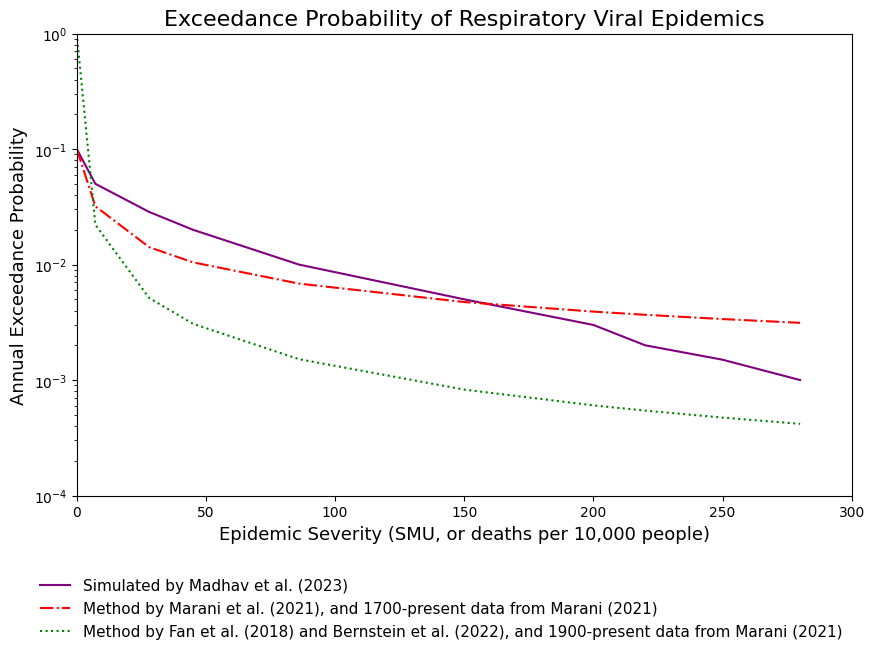

In [15]:
## Plot comparison across Madhav, Marani, and Bernstein-Fan 
plt.figure(figsize=(10, 6))

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle='-', label='Simulated by Madhav et al. (2023)')

## Plot for Marani
plt.plot(df_marani['severity'], df_marani['exceedance'], 
         color='red', linestyle='-.', label='Method by Marani et al. (2021), and 1700-present data from Marani (2021)')

## Plot for Bernstein 
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
         color='green', linestyle=':', label='Method by Fan et al. (2018) and Bernstein et al. (2022), and 1900-present data from Marani (2021)')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis limits
plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/04_resp_viral_comp_v2.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()



**Note:** Because Fan et al. (2018) and Bernstein et al. (2022)'s hyperbolic parametrization method requires the exceedance probability to be continuous and differentiable and starts at $r(0) = \Pr(S>0) =1$, a lot of weight is assigned to the lower end of the tail, making the upper end thinner compared to other methods. For reference, the hyperbolic approach offers an around $95\%$ chance of exceeding 0.01 SMU in a year, while the other two models offer a less than or equal to $10\%$ chance.



In [16]:
## Set up example severity
severity_example = 0.01

## Calculate Bernstein exceedance
bernstein_example = (1 + m * (1 - f) * severity_example)**(-1 - 1/(1 - f))

## Calculate Marani exceedance
marani_example = arrival ## Since 0.01 is the exceedance threshold


In [17]:
## Calculate Bernstein exceedance via log-linear interpolation
severity1 = 0.002
severity2 = 7.2
exceedance1 = 0.1
exceedance2 = 0.05

## Log-transform the probabilities
log_exceedance1 = np.log10(exceedance1)
log_exceedance2 = np.log10(exceedance2)

## Perform linear interpolation in the log scale
slope = (log_exceedance2 - log_exceedance1) / (severity2 - severity1)
log_madhav_example = log_exceedance1 + slope * (severity_example - severity1)

## Convert back from log scale to probability
madhav_example = 10 ** log_madhav_example

In [18]:
print(f'Annual exceedance probability of {severity_example} SMU:')
print(f'- Bernstein: {round(bernstein_example, 4)}' )
print(f'- Marani: {marani_example}' )
print(f'- Madhav: {round(madhav_example, 4)}' )

Annual exceedance probability of 0.01 SMU:
- Bernstein: 0.9541
- Marani: 0.1
- Madhav: 0.0999
